# 1 - Process MS MARCO dataset

* Project website: https://microsoft.github.io/msmarco/
* Download queries only (18Mb) - we are not interested in candidate documents - and unzip - https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz

## Download MS Marco dataset

In [1]:
!wget https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz

--2026-02-03 22:55:42--  https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz
Resolving msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)... 57.150.146.100
Connecting to msmarco.z22.web.core.windows.net (msmarco.z22.web.core.windows.net)|57.150.146.100|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18882551 (18M) [application/gzip]
Saving to: ‘queries.tar.gz’

queries.tar.gz      100%[===================>]  18.01M   166KB/s    in 40s     

2026-02-03 22:56:23 (463 KB/s) - ‘queries.tar.gz’ saved [18882551/18882551]



In [1]:
import pandas as pd
import requests
import json
import datetime

# For progress bars
from tqdm.notebook import tqdm
tqdm.pandas()

In [3]:
%%time

# Combine dev, eval, and train into a single set

queries = pd.concat([
    pd.read_csv('queries/queries.dev.tsv', sep='\t', names=['query_id', 'query_text']),
    pd.read_csv('queries/queries.eval.tsv', sep='\t', names=['query_id', 'query_text']),
    pd.read_csv('queries/queries.train.tsv', sep='\t', names=['query_id', 'query_text']),
]).drop_duplicates('query_id').drop_duplicates('query_text')

CPU times: user 438 ms, sys: 41.5 ms, total: 480 ms
Wall time: 484 ms


In [5]:
queries.shape

(1010916, 2)

In [4]:
queries.query('query_text == "most western point in portugal"')

,query_id,query_text
488917,459663,most western point in portugal


In [6]:
queries.query_text.sample(20).tolist()

['mouth breather medicine for cold',
 'where is clovelly',
 'tax consequence change custodian',
 'what type of food do teenagers eat',
 'things to do in the mesa az area',
 'how to raise credit',
 'here is the detail or here are',
 'what elements will darken lawn',
 'where is the original winnie the pooh located',
 'what is the purpose of ncua lending regulations',
 'weather in cappadocia turkey',
 'what is a mouth exostosis',
 'largest hydroelectric dam in us',
 'where does the name el nino originate from',
 'what is a slurry pump used for',
 'how does heat affect egg laying',
 'how many paper mills are in virginia',
 'what is the national defense act of 1916',
 'what causes a dog to pass blood',
 "what's a hillbilly?"]

In [7]:
queries.query_text.str.contains('near').mean()

0.0012226535142385718

<Axes: >

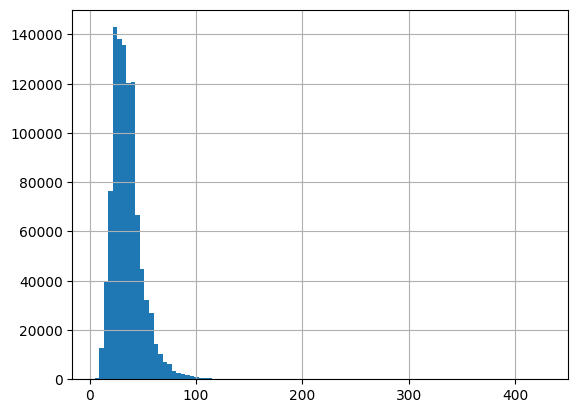

In [8]:
queries.query_text.str.len().hist(bins=100)

In [6]:
queries[queries.query_text.str.len().gt(100) & queries.query_text.str.len().lt(200)].query_text.tolist()

[') what is the acceleration of the upper block? (indicate the direction with the sign of your answer.)',
 '. What was the movement called humanism? How did it originate, and what were its main characteristics?',
 'what is offered to employees who have been determined to be at risk for exposure to bloodborne pathogens?',
 'who says she was looking into my eyes with that way she had of looking that made you wonder whether she really saw out of her own eyes.',
 'Although the Civil Rights Act of 1964 was the most comprehensive civil rights legislation ever considered it does not',
 'An infection that is spread by the blood or lymphatic system to large portions of the body is called:',
 'what is most commonly used financial performance measure when evaluating an organizations performance',
 'what is meant by the phrase social construction of disability? what are the implications of this term for assessment and identification of disabilities?',
 'what is meant by solution concentration and 

In [7]:
queries.to_csv('interim/queries.csv.zip', index=False)

## Precompute embeddings for all queries
- Use `BAAI/bge-small-en-v1.5` for all embeddings
- We'll sample points from the whole vector space so that we have a diverse set of examples

In [2]:
import numpy as np
from sentence_transformers import SentenceTransformer

/Users/ilya/miniconda3/lib/python3.11/site-packages/gunicorn/util.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [39]:
queries = pd.read_csv('interim/queries.csv.zip')

In [40]:
model = SentenceTransformer("BAAI/bge-small-en-v1.5")

In [ ]:
query_emb = model.encode(
    queries.query_text.tolist(),
    batch_size=32,
    normalize_embeddings=True, # cosine‑ready vectors
    show_progress_bar=True
) # --> outputs numpy array shape (len(queries), 384)

In [19]:
np.save('interim/query_emb.npy', query_emb)

## Sample 12k points to cover the whole vector space
- We know from the MS Marco paper that very roughly 5% of queries are labelled as Location
- Let's sample 12k points so can expect just over 500 positive (place-related) samples

In [3]:
import faiss

In [12]:
xb = np.load("interim/query_emb.npy").astype('float32')  # (n_queries, 384)

In [23]:
%%time

# xb: (N, d) float32 embeddings
N, d = xb.shape
k = 12000

# 1) train with zero iterations so centroids are just seeds
km = faiss.Kmeans(d, k,
                  niter=0,      # no Lloyd steps
                  gpu=True, 
                  verbose=True)
km.train(xb)

# 2) snap synthetic centroids back to real points
centroids = km.centroids                       # (k, d)
index = faiss.IndexFlatL2(d)
index.add(xb)
_, sample_inds = index.search(centroids, 1)    # (k,1)
sample_inds = sample_inds.ravel()              # (k,)

CPU times: user 13.5 s, sys: 381 ms, total: 13.9 s
Wall time: 11.2 s


In [26]:
np.save('interim/sample_inds.npy', sample_inds)

# Ask LLM to distinguish geospatial from non-geospatial

- Use Llama 3.1 on a subset of 12k samples
- Zero-shot to build a collection of 500 positive and 500 negative samples
- This collection will then be used in SetFit to build a classifier

Definitions of geographical/geospatial (we use both):

- [Kefalidis et al's (2024)](https://www.sciencedirect.com/science/article/pii/S1569843224005594?via%3Dihub): *"we define a question as geospatial if it requires qualitative or quantitative geographic knowledge to be answered"*
- [Mai's (2021)](https://agile-giss.copernicus.org/articles/2/8/2021/) *"we define geographic questions as questions that involve geographic entities (e.g., Los Angeles, Eastern Sierra), geographic concepts (e.g., feature types such as Building, City, State), or spatial relations (e.g. near to, north of, between) as parts of the natural language questions. Note that this definition is rather broad compared to related notions such as geo-analytical questions (Scheider et al., 2020) which require geo-analytical workflows (in GIS) to answer them."*

In [4]:
queries = pd.read_csv('interim/queries.csv.zip')
sample_inds = np.load('interim/sample_inds.npy')

In [5]:
def ask_llm(prompt, limit=9999, temp=0):
    """
    Sends the `prompt` to the LLM running locally via Ollama.
    Temperature = 0 / fixed seed will get consistent output between runs.
    Works much faster for shorter limits, so setting to 1
    for simple True/False judgments.
    """
    response = requests.post(
        url='http://localhost:11434/api/generate',
        json={
            'model': 'llama3.1',
            'prompt': prompt,
            'stream': False,
            'options': {
                'temperature': temp,
                # 'seed': 42, # remove to allow for randomness
                'num_predict': limit
            }
        }
    )

    try:
        return json.loads(response.text).get('response').strip()
    except:
        return ''



def is_geospatial(query_text, temp=0, n_runs=1):
    
    prompt = f"""Classify the search query as geospatial (true) or not (false).

A query is geospatial if it requires qualitative or quantitative geographic
knowledge of Earth-bound features to be answered. This is the case if the query involves:
- A geographic entity (named place on Earth: city, country, river, POI, address)
- A geographic concept (place type: city, lake, mountain, park, building)
- A spatial relation (near, within, north of, between, borders, crosses, distance)

Non-geospatial: anatomical, microscopic, astronomical, fictional, or abstract
'where' questions; queries needing no geographic knowledge.

Output only: true or false.

Examples:
  How far is Brighton from London -> true
  Capital of France -> true
  Population of Piraeus -> true
  Restaurants near Hyde Park -> true
  Where does Paris Hilton live -> true
  What city is Ebright Azimuth in -> true
  Where is the epimysium found -> false
  What is photosynthesis -> false

Query: '{query_text.strip()}'
Answer:
    """

    answers = []
    for i in range(n_runs):
        answers.append( ask_llm(prompt, 1, temp).lower() )
        
    return answers

In [8]:
is_geospatial('what is motionless')

['false']

In [9]:
is_geospatial('What city is Ebright Azimuth in')

['true']

In [6]:
subset = queries.iloc[sample_inds]

In [10]:
%%time

subset['is_geospatial'] = subset.query_text.progress_apply(
    lambda q: is_geospatial(q, 0.3, n_runs=5)
)

  0%|          | 0/12000 [00:00<?, ?it/s]

CPU times: user 3min 11s, sys: 1min 2s, total: 4min 13s
Wall time: 2h 48min 34s


<timed exec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [11]:
subset['is_geospatial_count'] = subset.is_geospatial.apply(
    lambda li: len( [x for x in li if x == 'true'] )
)

/var/folders/w6/kmxyhb092_3gsgy99f9_t01r0000gn/T/ipykernel_88787/1417303709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['is_geospatial_count'] = subset.is_geospatial.apply(


In [12]:
subset.is_geospatial_count.value_counts()

is_geospatial_count
0    10197
5     1566
1       72
3       65
4       56
2       44
Name: count, dtype: int64

In [13]:
subset.to_excel(
    f'interim/is_geospatial_20260428.xlsx',
    index=False
)

## Plots

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
majority_voting_data = (
    pd.read_excel('interim/is_spatial_20260125_edits.xlsx')
    .query('is_spatial_count > 0')
    .groupby('is_spatial_count')
    .agg({'human_check': ['count', 'mean']})
    ['human_check']
)

majority_voting_data['percent_true'] = majority_voting_data['mean'] * 100

majority_voting_data

,count,mean,percent_true
is_spatial_count,,,
1,43,0.697674,69.767442
2,16,0.937500,93.750000
3,20,0.850000,85.000000
4,36,0.833333,83.333333
5,628,0.985669,98.566879


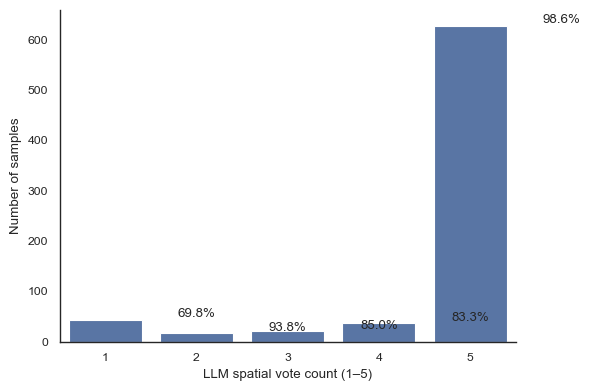

In [32]:
# Minimal style
sns.set_theme(style='white', context='paper')

fig, ax = plt.subplots(figsize=(6, 4))

# Bar plot
sns.barplot(
    data=majority_voting_data,
    x='is_spatial_count',
    y='count',
    ax=ax
)

# Percentage annotations
for i, row in majority_voting_data.iterrows():
    ax.text(
        i,
        row['count'],
        f"{row['percent_true']:.1f}%",
        ha='center',
        va='bottom'
    )

# Labels (no title – use caption in paper)
ax.set_xlabel('LLM spatial vote count (1–5)')
ax.set_ylabel('Number of samples')

sns.despine()
plt.tight_layout()

# For publication export:
# plt.savefig('figure.pdf', bbox_inches='tight')
plt.show()

In [3]:
# Let's look at the edits
data = (
    pd.read_excel('interim/is_spatial_20260125_edits.xlsx')
    .dropna(subset=['human_check'])
    .assign(
        human_check=lambda df_: df_.human_check.astype(bool)
    )
    .query('is_spatial_count >0 & not human_check')
)

In [20]:
data

,query_id,query_text,is_spatial,is_spatial_count,human_check,note
668,416626,is loma linda level i trauma center,"['false', 'true', 'false', 'false', 'false']",1,False,NaN
764,997757,where is the ssid located,"['false', 'false', 'false', 'false', 'true']",1,False,not geographical
1398,1002509,where was harry styles born and raised,"['false', 'true', 'true', 'true', 'true']",4,False,PII
1489,579747,what boundary is where the two plates meet in ...,"['true', 'true', 'true', 'true', 'true']",5,False,quiz-like question
1493,108419,cost per square foot to install brick patio,"['false', 'true', 'true', 'true', 'false']",3,False,no geo (I guess it could be like cost of somet...
2172,313356,how much does carpet cleaning cost per square ...,"['true', '**', 'true', 'false', 'true']",3,False,no geo
2467,208964,how big is an acre of land meters,"['true', 'true', 'true', 'true', 'true']",5,False,conversion of unit of measurement
2519,971617,where do subduction plate boundaries occur,"['true', 'true', 'false', 'true', '**']",3,False,NaN
2799,443390,lpn salary richmond va,"['true', 'true', 'true', 'true', 'true']",5,False,salary
2826,69292,can i navigate using a gpx track,"['true', 'true', 'true', 'true', 'true']",5,False,general GPS question
